Решение ОДУ u' = u * sin(x) методом Рунге-Кутты 4-го порядка
на отрезке [0, 10]

Число шагов: 100
Последняя точка x = 10.000000, u(x) = 629.068913
Точное значение в конце: 629.069482
Максимальная абсолютная ошибка: 6.621258e-04
Средняя абсолютная ошибка: 2.518237e-04


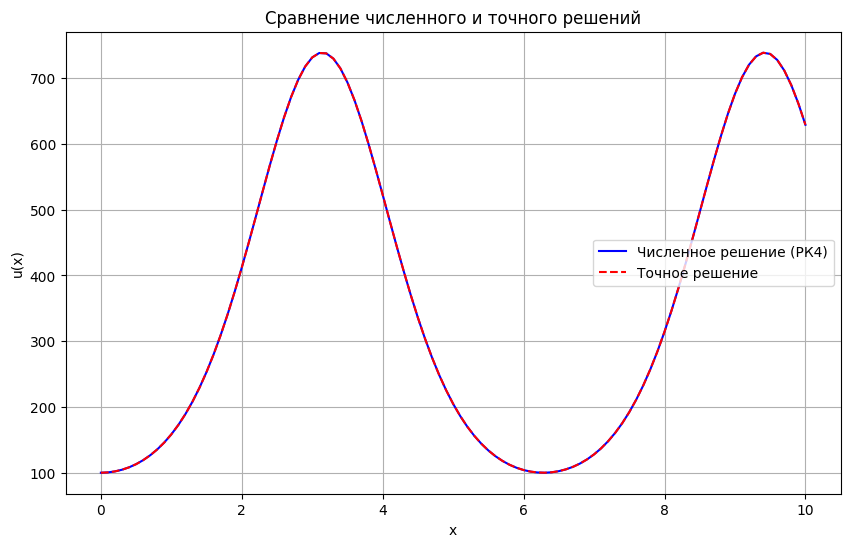

In [1]:
import math
import matplotlib.pyplot as plt

def runge_kutta_4(f, u0, x0, x_end, h):
    """
    Решает ОДУ u' = f(x, u) методом Рунге-Кутты 4-го порядка
    с постоянным шагом h на отрезке [x0, x_end].
    Возвращает списки x и u.
    """
    x = x0
    u = u0
    xs = [x]
    us = [u]
    
    while x < x_end - 1e-12:  # защита от погрешности плавающей точки
        # Корректируем последний шаг, чтобы точно попасть в x_end
        if x + h > x_end:
            h = x_end - x
        
        # Вычисление коэффициентов Рунге-Кутты
        k1 = f(x, u)
        k2 = f(x + h/2, u + h/2 * k1)
        k3 = f(x + h/2, u + h/2 * k2)
        k4 = f(x + h, u + h * k3)
        
        u = u + h/6 * (k1 + 2*k2 + 2*k3 + k4)
        x = x + h
        
        xs.append(x)
        us.append(u)
    
    return xs, us

def exact_solution(x, u0):
    """Точное решение задачи u' = u*sin(x) с начальным условием u(0)=u0"""
    return u0 * math.exp(1 - math.cos(x))

def main():
    print("Решение ОДУ u' = u * sin(x) методом Рунге-Кутты 4-го порядка")
    print("на отрезке [0, 10]")
    
    # Ввод данных пользователем
    try:
        u0 = float(input("Введите начальное значение u0 (по умолчанию 1): ") or "1")
        h = float(input("Введите шаг интегрирования h (например, 0.1): "))
    except ValueError:
        print("Ошибка ввода. Используем значения по умолчанию: u0=1, h=0.1")
        u0 = 1.0
        h = 0.1
    
    x0 = 0.0
    x_end = 10.0
    
    # Определяем правую часть ОДУ
    def f(x, u):
        return u * math.sin(x)
    
    # Вычисляем численное решение
    xs, us = runge_kutta_4(f, u0, x0, x_end, h)
    
    # Вычисляем точное решение в тех же точках
    u_exact = [exact_solution(x, u0) for x in xs]
    
    # Оценка ошибки
    errors = [abs(u_num - u_ex) for u_num, u_ex in zip(us, u_exact)]
    max_error = max(errors)
    mean_error = sum(errors) / len(errors)
    
    print(f"\nЧисло шагов: {len(xs)-1}")
    print(f"Последняя точка x = {xs[-1]:.6f}, u(x) = {us[-1]:.6f}")
    print(f"Точное значение в конце: {u_exact[-1]:.6f}")
    print(f"Максимальная абсолютная ошибка: {max_error:.6e}")
    print(f"Средняя абсолютная ошибка: {mean_error:.6e}")
    
    # Построение графиков
    plt.figure(figsize=(10, 6))
    plt.plot(xs, us, 'b-', label='Численное решение (РК4)')
    plt.plot(xs, u_exact, 'r--', label='Точное решение')
    plt.xlabel('x')
    plt.ylabel('u(x)')
    plt.title('Сравнение численного и точного решений')
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()

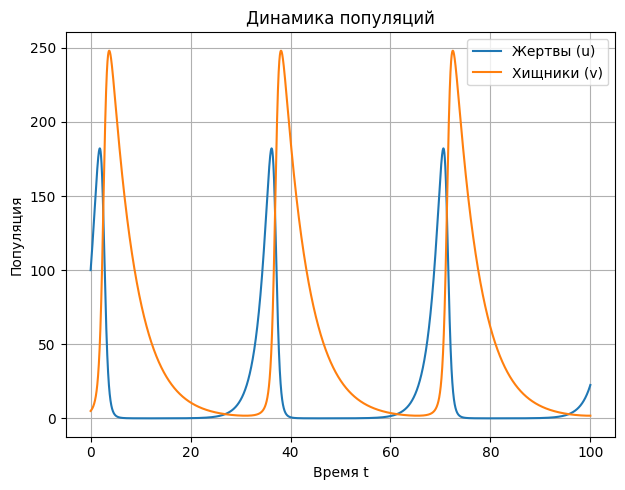

Параметры: a=0.5, b=0.01, c=0.2
Начальные условия: u0=100.0, v0=5.0
Решение на интервале [0, 100.0] с шагом h=0.0010
Последние значения: u(100.00) = 22.52, v(100.00) = 1.81


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Параметры модели (можно изменить)
a = 0.5   # коэффициент роста жертв
b = 0.01  # коэффициент взаимодействия
c = 0.2   # коэффициент смертности хищников

# Начальные условия
u0 = 100.0
v0 = 5.0

# Временной интервал
t0 = 0.0
t_end = 100.0
N = 1e5  # количество шагов
h = (t_end - t0) / N

# Система ОДУ
def f(t, y):
    u, v = y
    du = a * u - b * u * v
    dv = b * u * v - c * v
    return np.array([du, dv])

# Метод Рунге-Кутты 4-го порядка для системы
def runge_kutta_4(f, y0, t0, t_end, h):
    t_values = [t0]
    y_values = [y0]
    t = t0
    y = y0.copy()
    while t < t_end - 1e-12:
        k1 = f(t, y)
        k2 = f(t + h/2, y + h/2 * k1)
        k3 = f(t + h/2, y + h/2 * k2)
        k4 = f(t + h, y + h * k3)
        y = y + h/6 * (k1 + 2*k2 + 2*k3 + k4)
        t = t + h
        t_values.append(t)
        y_values.append(y.copy())
    return np.array(t_values), np.array(y_values)

# Решение
t, y = runge_kutta_4(f, np.array([u0, v0]), t0, t_end, h)
u = y[:, 0]
v = y[:, 1]

# Построение графиков
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t, u, label='Жертвы (u)')
plt.plot(t, v, label='Хищники (v)')
plt.xlabel('Время t')
plt.ylabel('Популяция')
plt.title('Динамика популяций')
plt.legend()
plt.grid(True)

plt.grid(True)

plt.tight_layout()
plt.show()

# Вывод информации
print(f"Параметры: a={a}, b={b}, c={c}")
print(f"Начальные условия: u0={u0}, v0={v0}")
print(f"Решение на интервале [0, {t_end}] с шагом h={h:.4f}")
print(f"Последние значения: u({t[-1]:.2f}) = {u[-1]:.2f}, v({t[-1]:.2f}) = {v[-1]:.2f}")

In [3]:
from scipy.integrate import solve_ivp

def lotka_voltera(t, y, a, b, c, d):
    u, v = y 
    dudt = a * u - b * u * v
    dvdt = -c*v + b * u * v
    return [dudt, dvdt]

a = 0.8
b = 0.02
c = 0.6
d = 0.015

u0 = 100 
v0 = 5
y0 = [u0, v0]

t_span = (0, 50)
t_eval = np.linspace(0, 50, 100)

sol = solve_ivp(
    lotka_voltera,
    t_span,
    y0,
    args=(a, b, c, d),
    t_eval=t_eval,
    methods="RK45",
    rtol=1e-6
)

plt.figure(figsize=(10, 7))

plt.subplot(sol.t, sol.y[0])
plt.subplot(sol.t, sol.y[1])
plt.grid(True)
plt.legend()
plt.xlabel("Время")
plt.ylabel("Популяция")
plt.title("Динамика популяции")

plt.subplot(2, 1, 2)
plt.plot(sol.y[0], sol.y[1], 'o-', ms=2, lw=1, color='darkgreen')
plt.grid(True)
plt.xlabel("Численность жертв u")
plt.ylabel("Численность хищников v")
plt.title("Фазовый портрет")

plt.tight_layout()
plt.show()

d:\projects_X\-\.venv\scipy\integrate\_ivp\ivp.py:623: UserWarning: The following arguments have no effect for a chosen solver: `methods`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


TypeError: subplot() takes 1 or 3 positional arguments but 2 were given

<Figure size 1000x700 with 0 Axes>